In [ ]:
import random
import numpy as np
from PIL import Image, ImageOps, ImageFilter
import torch
from torchvision import transforms

In [ ]:
def obtain_cutmix_box(img_size, p=0.5, size_min=0.02, size_max=0.4, ratio_1=0.3, ratio_2=1/0.3):
    mask = torch.zeros(img_size, img_size)
    if random.random() > p:
        return mask
    size = np.random.uniform(size_min, size_max) * img_size * img_size
    while True:
        ratio = np.random.uniform(ratio_1, ratio_2)
        cutmix_w = int(np.sqrt(size / ratio))
        cutmix_h = int(np.sqrt(size * ratio))
        x = np.random.randint(0, img_size)
        y = np.random.randint(0, img_size)
        if x + cutmix_w <= img_size and y + cutmix_h <= img_size:
            break
    mask[y:y + cutmix_h, x:x + cutmix_w] = 1

    return mask

In [28]:
mask = obtain_cutmix_box(img_size=32, p=0.5)
print("掩码形状:", mask.shape)
print("掩码中1的区域占比:", mask.sum()/(32*32))
print("掩码示例（前10行前10列）:")
print(mask[:15, :15].numpy())

掩码形状: torch.Size([32, 32])
掩码中1的区域占比: tensor(0.2871)
掩码示例（前10行前10列）:
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

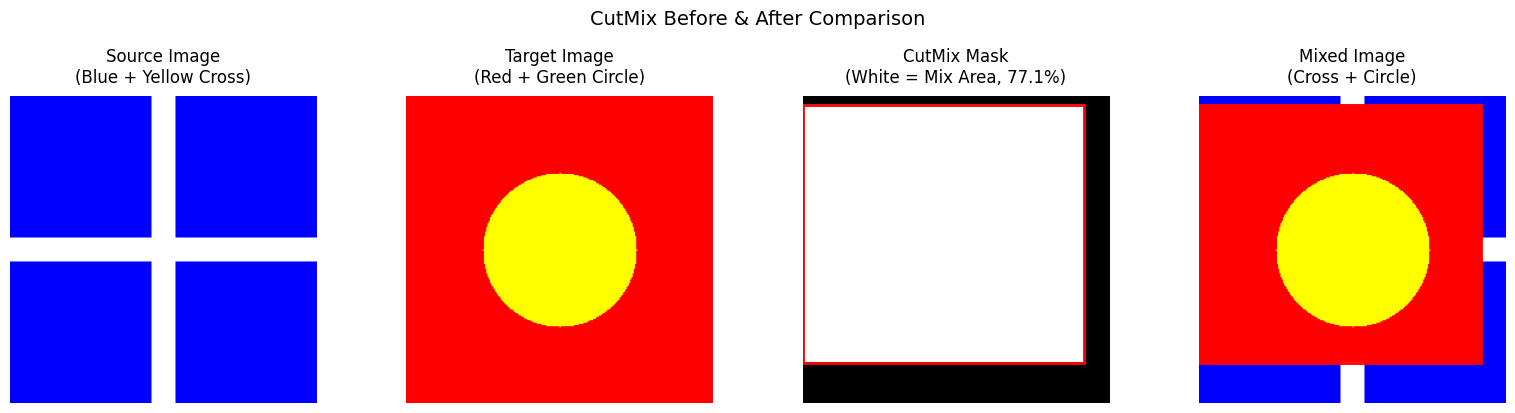

In [32]:
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 原函数不变（确保可独立运行）
def obtain_cutmix_box(img_size, p=0.5, size_min=0.02, size_max=0.4, ratio_1=0.3, ratio_2=1/0.3):
    mask = torch.zeros(img_size, img_size)
    if random.random() > p:
        return mask
    size = np.random.uniform(size_min, size_max) * img_size * img_size
    while True:
        ratio = np.random.uniform(ratio_1, ratio_2)
        cutmix_w = int(np.sqrt(size / ratio))
        cutmix_h = int(np.sqrt(size * ratio))
        x = np.random.randint(0, img_size)
        y = np.random.randint(0, img_size)
        if x + cutmix_w <= img_size and y + cutmix_h <= img_size:
            break
    mask[y:y + cutmix_h, x:x + cutmix_w] = 1
    return mask

# 生成差异明显的RGB测试图（无需中文）
def generate_test_rgb_image(img_size=256, type="source"):
    """生成测试用RGB图像：source（蓝底+黄色十字），target（红底+绿色圆形）"""
    img = np.zeros((img_size, img_size, 3), dtype=np.uint8)
    
    if type == "source":
        # Source: Blue background + Yellow cross
        img[:, :, 2] = 255  # 蓝色通道
        img[img_size//2 - 10 : img_size//2 + 10, :, :2] = 255  # 黄色横线
        img[:, img_size//2 - 10 : img_size//2 + 10, :2] = 255  # 黄色竖线
    else:
        # Target: Red background + Green circle
        img[:, :, 0] = 255  # 红色通道
        y, x = np.ogrid[:img_size, :img_size]
        center = (img_size//2, img_size//2)
        radius = img_size//4
        mask_circle = (x - center[0])**2 + (y - center[1])**2 <= radius**2
        img[mask_circle, 1] = 255  # 绿色圆形
    
    return img

# CutMix核心操作（不变）
def cutmix_images(img1, img2, mask):
    mask_rgb = mask.numpy()[..., np.newaxis].repeat(3, axis=2)
    mixed_img = (img1.astype(np.float32) * (1 - mask_rgb) + img2.astype(np.float32) * mask_rgb).astype(np.uint8)
    return mixed_img

# 固定随机种子（可复现）
random.seed(42)
np.random.seed(42)

# 生成数据
img_size = 256
source_img = generate_test_rgb_image(img_size, type="source")  # 蓝底黄十字
target_img = generate_test_rgb_image(img_size, type="target")  # 红底绿圆
mask = obtain_cutmix_box(img_size, p=1.0, size_min=0.7, size_max=0.9, ratio_1=0.5, ratio_2=2.0)  # 强制触发
mixed_img = cutmix_images(source_img, target_img, mask)

# 提取掩码区域信息（用于标注）
mask_np = mask.numpy()
y_coords, x_coords = np.where(mask_np == 1)
x1, y1 = x_coords.min(), y_coords.min()
cutmix_w = x_coords.max() - x1 + 1
cutmix_h = y_coords.max() - y1 + 1
mix_ratio = mask.sum()/(img_size**2)  # 混合区域占比

# 绘制对比图（全英文标注，无字体依赖）
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# 1. 源图像
axes[0].imshow(source_img)
axes[0].set_title('Source Image\n(Blue + Yellow Cross)', fontsize=12, pad=10)
axes[0].axis('off')

# 2. 目标图像
axes[1].imshow(target_img)
axes[1].set_title('Target Image\n(Red + Green Circle)', fontsize=12, pad=10)
axes[1].axis('off')

# 3. CutMix掩码
axes[2].imshow(mask_np, cmap='gray')
axes[2].set_title(f'CutMix Mask\n(White = Mix Area, {mix_ratio:.1%})', fontsize=12, pad=10)
axes[2].axis('off')
# 标注混合区域
rect = Rectangle((x1, y1), cutmix_w, cutmix_h, linewidth=2, edgecolor='red', facecolor='none')
axes[2].add_patch(rect)

# 4. 混合后图像
axes[3].imshow(mixed_img)
axes[3].set_title('Mixed Image\n(Cross + Circle)', fontsize=12, pad=10)
axes[3].axis('off')
# 标注混合区域
rect2 = Rectangle((x1, y1), cutmix_w, cutmix_h, linewidth=2, edgecolor='red', facecolor='none')
axes[3].add_patch(rect2)

# 总标题
plt.suptitle('CutMix Before & After Comparison', fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

# 测试二，blur模糊测试

In [6]:
def blur(img, p=0.5):
    if random.random() < p:
        sigma = np.random.uniform(0.1, 2.0)
        img = img.filter(ImageFilter.GaussianBlur(radius=sigma))
    return img

开始blur效果演示...
创建简单测试图像...


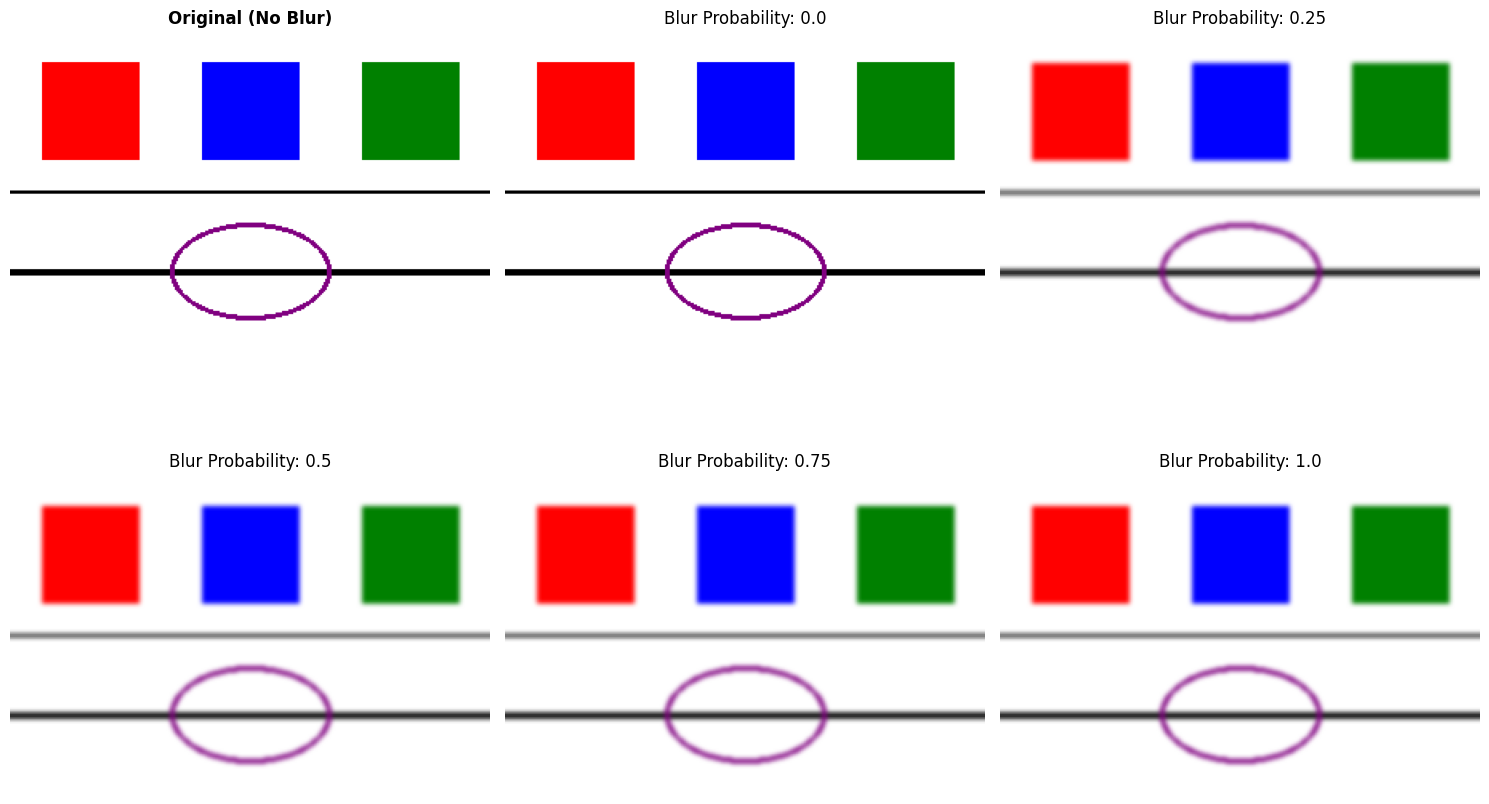


测试完成！可以清楚地看到blur函数的效果。

演示完成！可以清楚地看到blur函数的效果。


In [26]:
import random
import numpy as np
from PIL import Image, ImageFilter, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def blur(img, p=0.5):
    """应用高斯模糊的数据增强函数"""
    if random.random() < p:
        sigma = np.random.uniform(0.1, 2.0)
        img = img.filter(ImageFilter.GaussianBlur(radius=sigma))
    return img

def create_test_image():
    """
    创建一个包含清晰文本和几何图形的测试图像
    修复中文字体问题
    """
    # 创建一个白色背景的图像
    img = Image.new('RGB', (400, 300), color='white')
    draw = ImageDraw.Draw(img)
    
    # 绘制一些彩色矩形
    draw.rectangle([50, 50, 150, 150], fill='red')
    draw.rectangle([200, 50, 300, 150], fill='blue')
    draw.rectangle([50, 180, 150, 250], fill='green')
    draw.rectangle([200, 180, 300, 250], fill='purple')
    
    # 绘制一些线条
    draw.line([0, 0, 400, 300], fill='black', width=3)
    draw.line([400, 0, 0, 300], fill='black', width=3)
    
    # 绘制圆形
    draw.ellipse([150, 100, 250, 200], outline='orange', width=5)
    
    # 不使用中文字体，改用英文标识
    draw.text((100, 10), "BLUR TEST", fill='black')
    draw.text((80, 270), "SHARP vs BLURRED", fill='black')
    
    return img

def setup_chinese_font():
    """
    设置中文字体支持，避免字体警告
    """
    # 查找系统中的中文字体
    font_paths = fm.findSystemFonts()
    chinese_fonts = []
    
    # 常见中文字体名称
    chinese_font_names = ['SimHei', 'SimSun', 'Microsoft YaHei', 'STHeiti', 'PingFang']
    
    for font_path in font_paths:
        try:
            font_name = fm.FontProperties(fname=font_path).get_name()
            if any(chinese_name in font_name for chinese_name in chinese_font_names):
                chinese_fonts.append(font_path)
        except:
            continue
    
    # 如果找到中文字体，设置matplotlib使用
    if chinese_fonts:
        plt.rcParams['font.sans-serif'] = ['SimHei'] + plt.rcParams['font.sans-serif']
    else:
        # 如果没有中文字体，使用英文字体并避免unicode警告
        plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
    
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

def demonstrate_blur_effect():
    """
    演示blur函数的效果，通过对比原图和模糊图来展示差异
    修复字体警告问题
    """
    # 设置字体
    setup_chinese_font()
    
    print("创建测试图像...")
    original_img = create_test_image()
    
    # 设置随机种子以便复现结果
    random.seed(42)
    np.random.seed(42)
    
    print("应用blur函数 (p=1.0 确保总是应用模糊)...")
    blurred_img = blur(original_img, p=1.0)
    
    # 显示结果 - 使用英文标题避免字体问题
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # 显示原图
    axes[0].imshow(original_img)
    axes[0].set_title('Original Image (Sharp)', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # 显示模糊图像
    axes[1].imshow(blurred_img)
    axes[1].set_title('Blurred Image', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # 让我们再创建一个极端对比的例子
    print("\n创建极端对比示例...")
    extreme_img = create_test_image()
    
    # 用强模糊效果 (sigma=5.0)
    strong_blur = extreme_img.filter(ImageFilter.GaussianBlur(radius=5.0))
    
    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 6))
    
    axes2[0].imshow(extreme_img)
    axes2[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes2[0].axis('off')
    
    axes2[1].imshow(strong_blur)
    axes2[1].set_title('Strong Blur (radius=5.0)', fontsize=14, fontweight='bold')
    axes2[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # 演示概率效果
    print("\n演示不同概率的blur效果:")
    test_img = create_test_image()
    
    probabilities = [0.0, 0.25, 0.5, 0.75, 1.0]
    results = []
    
    # 为每个概率生成结果（固定随机种子）
    for i, p in enumerate(probabilities):
        random.seed(i*100)  # 为每个概率设置不同的种子
        np.random.seed(i*100)
        result = blur(test_img, p=p)
        results.append(result)
    
    # 显示不同概率的效果
    fig3, axes3 = plt.subplots(1, 5, figsize=(20, 4))
    
    for i, (p, img) in enumerate(zip(probabilities, results)):
        axes3[i].imshow(img)
        if p == 0.0:
            title = f'p={p}\n(Always Sharp)'
        elif p == 1.0:
            title = f'p={p}\n(Always Blurred)'
        else:
            title = f'p={p}\n({"Blurred" if p > 0.5 else "Sharp"})'
        axes3[i].set_title(title, fontsize=12)
        axes3[i].axis('off')
    
    plt.suptitle('Blur Effect with Different Probabilities', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n效果说明:")
    print("1. 文本部分: 模糊后文字边缘变得柔和，难以辨认")
    print("2. 边缘部分: 锐利的边缘变得平滑")
    print("3. 颜色过渡: 颜色边界变得不那么明显")
    print("4. 几何图形: 圆形、线条等变得不那么锐利")

def analyze_blur_parameters():
    """
    分析不同sigma值对模糊效果的影响
    """
    print("\n分析不同sigma值的影响:")
    test_img = create_test_image()
    
    sigma_values = [0.1, 0.5, 1.0, 2.0, 5.0]
    blurred_images = []
    
    for sigma in sigma_values:
        blurred = test_img.filter(ImageFilter.GaussianBlur(radius=sigma))
        blurred_images.append(blurred)
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    
    for i, (sigma, img) in enumerate(zip(sigma_values, blurred_images)):
        axes[i].imshow(img)
        axes[i].set_title(f'σ={sigma}', fontsize=14)
        axes[i].axis('off')
    
    plt.suptitle('Gaussian Blur Effect with Different Sigma Values', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Sigma值越大，模糊效果越强:")
    print("- σ=0.1: 几乎无模糊效果")
    print("- σ=1.0: 轻度模糊")
    print("- σ=2.0: 中度模糊")
    print("- σ=5.0: 强烈模糊")

# 简化版本的测试函数，专门用于测试已有的图片
def test_blur_with_existing_images():
    """
    使用已有的图片测试blur效果，避免字体问题
    """
    # 设置字体
    setup_chinese_font()
    
    # 创建简单的几何图形测试图像
    def create_simple_test_image():
        img = Image.new('RGB', (300, 200), color='white')
        draw = ImageDraw.Draw(img)
        
        # 绘制彩色方块
        draw.rectangle([20, 20, 80, 80], fill='red')
        draw.rectangle([120, 20, 180, 80], fill='blue')
        draw.rectangle([220, 20, 280, 80], fill='green')
        
        # 绘制线条
        draw.line([0, 100, 300, 100], fill='black', width=2)
        draw.line([0, 150, 300, 150], fill='black', width=4)
        
        # 绘制圆形
        draw.ellipse([100, 120, 200, 180], outline='purple', width=3)
        
        return img
    
    print("创建简单测试图像...")
    test_img = create_simple_test_image()
    
    # 测试不同概率
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    probabilities = [0.0, 0.25, 0.5, 0.75, 1.0]
    
    # 原始图像
    axes[0, 0].imshow(test_img)
    axes[0, 0].set_title('Original (No Blur)', fontweight='bold')
    axes[0, 0].axis('off')
    
    # 不同概率的模糊效果
    positions = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]
    for i, (p, pos) in enumerate(zip(probabilities, positions)):
        # 为每次测试设置相同的随机种子以确保一致性
        random.seed(123)
        np.random.seed(123)
        blurred = blur(test_img, p=p)
        axes[pos[0], pos[1]].imshow(blurred)
        axes[pos[0], pos[1]].set_title(f'Blur Probability: {p}')
        axes[pos[0], pos[1]].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n测试完成！可以清楚地看到blur函数的效果。")

# 运行演示
if __name__ == "__main__":
    print("开始blur效果演示...")
    try:
        test_blur_with_existing_images()
        print("\n演示完成！可以清楚地看到blur函数的效果。")
    except Exception as e:
        print(f"测试过程中出现错误: {e}")
        print("使用简化版本进行测试...")
        # 如果上面的测试失败，使用最基本的测试
        setup_chinese_font()
        simple_img = Image.new('RGB', (200, 100), color='red')
        draw = ImageDraw.Draw(simple_img)
        draw.rectangle([50, 25, 150, 75], fill='blue')
        
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(simple_img)
        plt.title('Original')
        plt.axis('off')
        
        blurred = simple_img.filter(ImageFilter.GaussianBlur(radius=2.0))
        plt.subplot(1, 2, 2)
        plt.imshow(blurred)
        plt.title('Blurred')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        print("简化测试完成！")

# 测试三，ColorJitter,RandomGrayscale使用

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

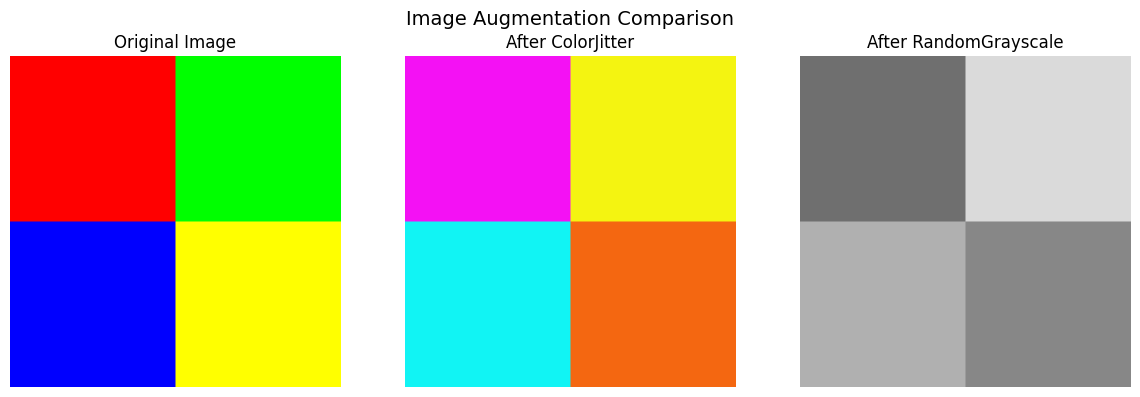

In [39]:
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
# ---------------------- 步骤1：生成测试图像（RGB图，差异明显） ----------------------
def generate_test_image():
    """生成一张彩色测试图（红、绿、蓝、黄四个色块）"""
    img = np.zeros((200, 200, 3), dtype=np.uint8)
    # 左上：红色 (R=255, G=0, B=0)
    img[0:100, 0:100, 0] = 255
    # 右上：绿色 (R=0, G=255, B=0)
    img[0:100, 100:200, 1] = 255
    # 左下：蓝色 (R=0, G=0, B=255)
    img[100:200, 0:100, 2] = 255
    # 右下：黄色 (R=255, G=255, B=0)
    img[100:200, 100:200, :2] = 255
    return Image.fromarray(img)

# ---------------------- 步骤2：定义增强操作 ----------------------
# 颜色抖动（和目标代码一致）
color_jitter = transforms.ColorJitter(0.5, 0.5, 0.5, 0.25)
# 随机灰度化（和目标代码一致，p是概率）
random_grayscale = transforms.RandomGrayscale(p=0.8)

# ---------------------- 步骤3：生成图像并对比 ----------------------
# 原始图像
img_original = generate_test_image()

# 经过ColorJitter后的图像（每次运行效果不同，因为随机）
img_jittered = color_jitter(img_original)

# 再经过RandomGrayscale后的图像（20%概率灰度化）
img_final = random_grayscale(img_jittered)

# ---------------------- 步骤4：可视化对比 ----------------------
plt.figure(figsize=(12, 4))

# 原始图
plt.subplot(1, 3, 1)
plt.imshow(img_original)
plt.title('Original Image', fontsize=12)
plt.axis('off')

# ColorJitter后
plt.subplot(1, 3, 2)
plt.imshow(img_jittered)
plt.title('After ColorJitter', fontsize=12)
plt.axis('off')

# RandomGrayscale后
plt.subplot(1, 3, 3)
plt.imshow(img_final)
plt.title('After RandomGrayscale', fontsize=12)
plt.axis('off')

plt.suptitle('Image Augmentation Comparison', fontsize=14)
plt.tight_layout()
plt.show()